In [1]:
%pip install matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\hcombrinck\OneDrive\Astroray\raytracer_addon\build\blender_addon\Release')

import raytracer_blender


In [3]:
renderer = raytracer_blender.Renderer()
print("Module version:", raytracer_blender.__version__)

Module version: 3.0.0


In [4]:
#How to use the module
print(attribiutes := dir(raytracer_blender))

['Renderer', '__doc__', '__features__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '__version__']


In [11]:
#Print all available functions
for attribute in attribiutes:
    if callable(getattr(raytracer_blender, attribute)):
        print(attribute)

#Print all functions of the Renderer class
print(dir(renderer))

help(renderer)

Renderer
['__class__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '_pybind11_conduit_v1_', 'add_mesh', 'add_sphere', 'add_triangle', 'add_volume', 'clear', 'create_material', 'create_procedural_texture', 'get_albedo_buffer', 'get_height', 'get_normal_buffer', 'get_width', 'load_texture', 'render', 'set_adaptive_sampling', 'setup_camera']
Help on Renderer in module raytracer_blender object:

class Renderer(pybind11_builtins.pybind11_object)
 |  Method resolution order:
 |      Renderer
 |      pybind11_builtins.pybind11_object
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(...)
 |      __init__(self: raytracer_blender.Renderer) -> None
 |  
 |  add_mesh(...)
 |      add_mesh(self: raytrace

Rendering test scene...


(np.float64(-0.5), np.float64(639.5), np.float64(359.5), np.float64(-0.5))

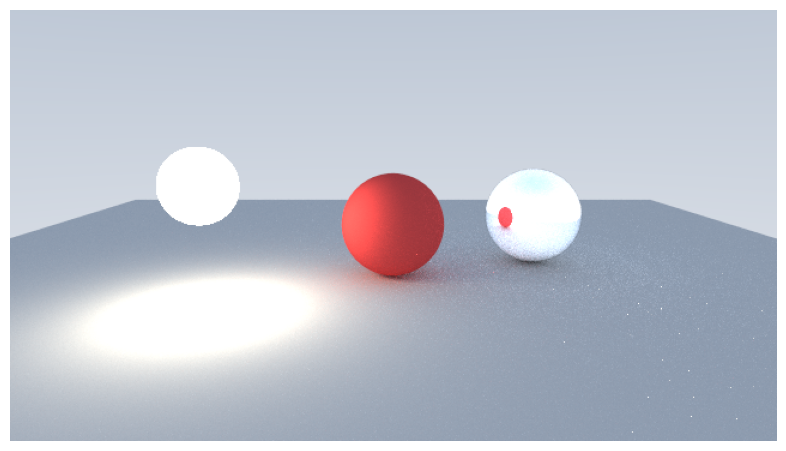

In [13]:
# Simple test scene using existing `renderer` from raytracer_blender
# This cell expects `renderer` and `plt` to already be available in the notebook.

# Reset scene
renderer.clear()

# Create materials
mat_ground = renderer.create_material("diffuse", [0.8, 0.8, 0.8], {})
mat_red = renderer.create_material("diffuse", [0.9, 0.1, 0.1], {})
mat_metal = renderer.create_material("metal", [0.8, 0.8, 0.8], {"roughness": 0.02})
mat_light = renderer.create_material("emission", [1.0, 0.9, 0.7], {"intensity": 30.0})

# Ground plane (two triangles)
renderer.add_triangle(
    v0=[-5.0, -0.01, -5.0],
    v1=[5.0, -0.01, -5.0],
    v2=[5.0, -0.01, 5.0],
    material_id=mat_ground
)
renderer.add_triangle(
    v0=[-5.0, -0.01, -5.0],
    v1=[5.0, -0.01, 5.0],
    v2=[-5.0, -0.01, 5.0],
    material_id=mat_ground
)

# Spheres
renderer.add_sphere(center=[0.0, 0.5, 0.0], radius=0.5, material_id=mat_red)
renderer.add_sphere(center=[-1.5, 0.5, -0.5], radius=0.5, material_id=mat_metal)
renderer.add_sphere(center=[1.5, 1.0, 1.0], radius=0.3, material_id=mat_light)

# Camera
renderer.setup_camera(
    look_from=[0.0, 1.5, 5.0],
    look_at=[0.0, 0.5, 0.0],
    vup=[0.0, -1.0, 0.0],
    vfov=45.0,
    aspect_ratio=16/9,
    aperture=0.0,
    focus_dist=5.0,
    width=640,
    height=360
)

# Render
print("Rendering test scene...")
pixels = renderer.render(samples_per_pixel=128, max_depth=4)

# Display
plt.figure(figsize=(10, 5.6))
plt.imshow(pixels)
plt.axis('off')

Rendering enhanced scene...


(np.float64(-0.5), np.float64(899.5), np.float64(505.5), np.float64(-0.5))

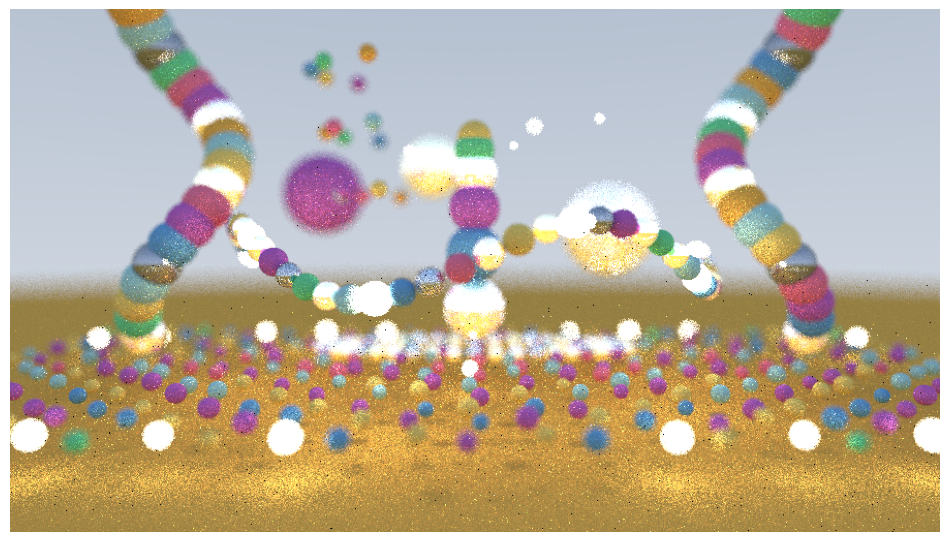

In [39]:
import math
import random

# Keep existing materials if present; otherwise create defaults.
if 'mat_ground' not in globals():
    mat_ground = renderer.create_material("diffuse", [0.48, 0.48, 0.50], {})
if 'mat_white' not in globals():
    mat_white = renderer.create_material("diffuse", [0.98, 0.98, 1.00], {})
if 'mat_metal' not in globals():
    mat_metal = renderer.create_material("metal", [0.75, 0.68, 0.60], {"roughness": 0.03})
if 'mat_light' not in globals():
    mat_light = renderer.create_material("emission", [1.0, 0.95, 0.85], {"intensity": 18.0})
if 'mat_green' not in globals():
    mat_green = renderer.create_material("diffuse", [0.35, 0.9, 0.55], {})

renderer.clear()

# Accents: colorful diffuse materials + a few metals and subtle emissives
palette = [
    [0.92, 0.55, 0.12],
    [0.18, 0.48, 0.88],
    [0.62, 0.18, 0.72],
    [0.95, 0.25, 0.45],
    [0.20, 0.85, 0.45],
    [0.98, 0.78, 0.24],
    [0.45, 0.82, 0.92],
]
accent_mats = [renderer.create_material("diffuse", c, {}) for c in palette]
metal_mats = [
    renderer.create_material("metal", [0.86, 0.80, 0.75], {"roughness": 0.04}),
    renderer.create_material("metal", [0.55, 0.62, 0.75], {"roughness": 0.12}),
    renderer.create_material("metal", [0.95, 0.90, 0.65], {"roughness": 0.02}),
]
soft_glow = renderer.create_material("emission", [1.0, 0.9, 0.7], {"intensity": 10.0})
strong_glow = renderer.create_material("emission", [1.0, 0.8, 0.5], {"intensity": 40.0})

# Ground (huge sphere like before) - reuse mat_ground id
renderer.add_sphere(center=[0.0, -1000.25, 0.0], radius=1000.0, material_id=mat_ground)

# Central cluster: a stack of varied spheres with alternating materials, creating a "totem"
center_x = 0.0
center_z = 0.0
for i in range(9):
    r = 0.9 - i * 0.08
    y = 0.9 + i * (r * 0.9)
    mat = metal_mats[i % len(metal_mats)] if (i % 3 == 0) else accent_mats[i % len(accent_mats)]
    renderer.add_sphere(center=[center_x, y, center_z], radius=max(0.18, r * 0.45), material_id=mat)

# Floating lanterns: small emissive spheres in a loose arc with halos (a faint emission inside a colored shell)
for j, angle in enumerate([ -0.8, -0.4, 0.0, 0.45, 0.9 ]):
    for k in range(3):
        t = angle + (k - 1) * 0.08
        x = 2.2 * math.cos(t) + 0.2 * (k - 1)
        z = -1.2 + 1.2 * math.sin(t)
        y = 2.5 + 0.9 * k
        # emissive core
        renderer.add_sphere(center=[x, y, z], radius=0.08, material_id=strong_glow)
        # colored translucent shell approximated by a thin diffuse sphere using accent color
        shell_mat = accent_mats[(j * 3 + k) % len(accent_mats)]
        renderer.add_sphere(center=[x, y, z], radius=0.12, material_id=shell_mat)

# Arch of glossy pebbles with alternating glow pebbles for a festive curtain
for i in range(36):
    t = (i / 35.0) * math.pi  # half circle
    R = 3.2
    x = R * math.cos(t)
    z = -0.8 + R * math.sin(t)
    y = 1.6 + 0.4 * math.sin(4 * t)
    r = 0.14 + 0.02 * ((i % 5) / 4.0)
    if i % 7 == 0:
        mid = strong_glow
    elif i % 2 == 0:
        mid = metal_mats[i % len(metal_mats)]
    else:
        mid = accent_mats[i % len(accent_mats)]
    renderer.add_sphere(center=[x, y, z], radius=r, material_id=mid)

# Spiral towers: two mirrored spirals with gradually changing color and radius
for side in (-1, 1):
    base_x = 4.0 * side
    for step in range(20):
        t = step * 0.35
        radius = 0.28 + 0.005 * step
        x = base_x + 0.6 * math.cos(t) * side
        z = -0.4 + 0.6 * math.sin(t)
        y = 0.5 + step * 0.25
        mat = accent_mats[(step + (0 if side < 0 else 3)) % len(accent_mats)] if step % 4 else metal_mats[step % len(metal_mats)]
        renderer.add_sphere(center=[x, y, z], radius=radius, material_id=mat)

# Reflective ring pool: many small metal discs forming a circular "mirror" ring on the ground
ring_R = 2.4
for i in range(48):
    ang = (i / 48.0) * 2.0 * math.pi
    x = ring_R * math.cos(ang)
    z = 0.6 * math.sin(ang) - 1.6
    y = 0.12
    r = 0.12 + 0.02 * (0.5 - abs((i % 6) - 3) / 3.0)
    renderer.add_sphere(center=[x, y, z], radius=r, material_id=metal_mats[(i+1) % len(metal_mats)])

# Dense "pebbles" field in front (more varied and colorful than before)
for ix in range(-12, 13):
    for iz in range(-6, 7):
        x = ix * 0.55 + (0.06 if (ix + iz) % 2 == 0 else -0.06)
        z = iz * 0.55 + (0.03 if (ix - iz) % 3 == 0 else -0.03)
        y = 0.10 + 0.02 * ((ix * iz) % 4)
        radius = 0.08 + 0.03 * ((ix + iz) % 5) / 4.0
        idx = (abs(ix) * 31 + abs(iz) * 17) % 100
        if idx % 19 == 0:
            mid = soft_glow
        elif idx % 7 == 0:
            mid = metal_mats[idx % len(metal_mats)]
        else:
            mid = accent_mats[idx % len(accent_mats)]
        renderer.add_sphere(center=[x, y, z], radius=radius, material_id=mid)

# A few large, glossy "planets" hovering behind the totem for depth
for i, (cx, cz, color_idx) in enumerate(([ -2.4, -3.2, 0 ], [ 2.6, -2.8, 2 ], [ 0.8, -4.2, 5 ])):
    mat = metal_mats[i % len(metal_mats)] if i % 2 == 0 else accent_mats[color_idx % len(accent_mats)]
    renderer.add_sphere(center=[cx, 2.0 + i * 0.6, cz], radius=0.8 - 0.12 * i, material_id=mat)
    # small halo / inner glow
    renderer.add_sphere(center=[cx, 2.0 + i * 0.6, cz], radius=0.36 - 0.06 * i, material_id=soft_glow)

# Subtle floating dust/fog by scattering many tiny faint emissive dots (gives atmosphere)
for i in range(120):
    ang = random.random() * math.pi * 2.0
    rad = 1.0 + random.random() * 4.0
    x = rad * math.cos(ang) + (random.random() - 0.5) * 0.6
    z = -1.0 + rad * 0.5 * math.sin(ang) + (random.random() - 0.5) * 0.6
    y = 0.6 + random.random() * 3.2
    r = 0.02 + random.random() * 0.03
    if random.random() < 0.08:
        renderer.add_sphere(center=[x, y, z], radius=r, material_id=soft_glow)

# Camera: wider, slightly lower, with some depth of field for a cinematic look
renderer.setup_camera(
    look_from=[0.0, 1.8, 9.0],
    look_at=[0.0, 1.4, -0.2],
    vup=[0.0, -1.0, 0.0],
    vfov=42.0,
    aspect_ratio=16/9,
    aperture=0.45,
    focus_dist=7.5,
    width=900,
    height=506
)

# Render
print("Rendering enhanced scene...")
pixels = renderer.render(samples_per_pixel=32, max_depth=8)

# Display (use existing plt if available)
plt.figure(figsize=(12, 6.8))
plt.imshow(pixels)
plt.axis('off')


Rendering the most interesting scene ever...


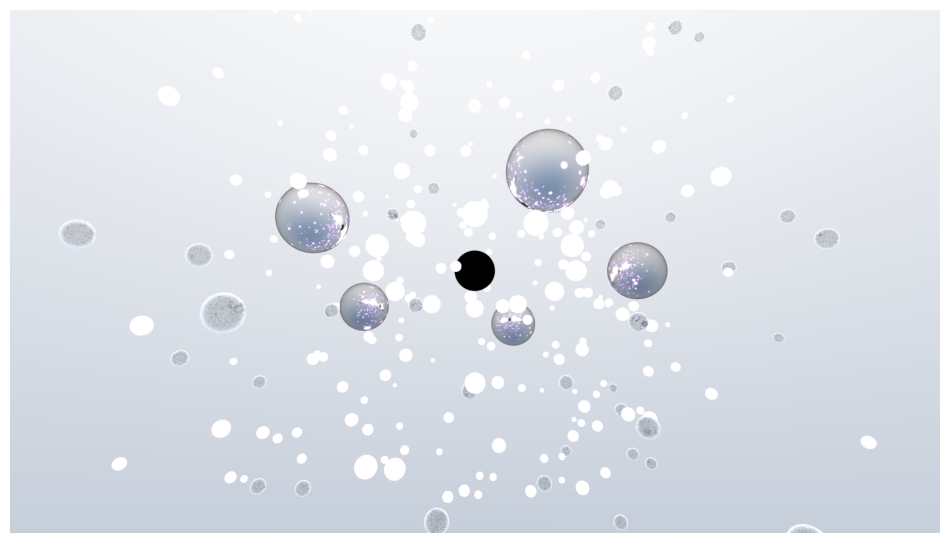

In [41]:
# Clear the current scene
renderer.clear()

# Materials
mat_black_hole = renderer.create_material("emission", [0.0, 0.0, 0.0], {"intensity": 0.0})
mat_star = renderer.create_material("emission", [1.0, 0.9, 0.7], {"intensity": 50.0})
mat_planet = renderer.create_material("diffuse", [0.2, 0.4, 0.8], {})
mat_ring = renderer.create_material("metal", [0.9, 0.9, 0.9], {"roughness": 0.1})
mat_nebula = renderer.create_material("emission", [0.5, 0.2, 0.8], {"intensity": 10.0})

# Black hole at the center
renderer.add_sphere(center=[0.0, 0.0, 0.0], radius=1.0, material_id=mat_black_hole)

# Orbiting stars
for i in range(12):
    angle = i * (2 * math.pi / 12)
    x = 5.0 * math.cos(angle)
    z = 5.0 * math.sin(angle)
    renderer.add_sphere(center=[x, 0.0, z], radius=0.5, material_id=mat_star)

# Planets with rings
for i in range(5):
    angle = i * (2 * math.pi / 5)
    x = 8.0 * math.cos(angle)
    z = 8.0 * math.sin(angle)
    renderer.add_sphere(center=[x, 0.0, z], radius=1.0, material_id=mat_planet)
    for j in range(3):
        renderer.add_sphere(center=[x, 0.0, z], radius=1.2 + j * 0.1, material_id=mat_ring)

# Nebula cloud
for _ in range(200):
    x = random.uniform(-10, 10)
    y = random.uniform(-10, 10)
    z = random.uniform(-10, 10)
    r = random.uniform(0.1, 0.3)
    renderer.add_sphere(center=[x, y, z], radius=r, material_id=mat_nebula)

# Floating crystals
mat_crystal = renderer.create_material("dielectric", [1.0, 1.0, 1.0], {"ior": 1.5})
for _ in range(50):
    x = random.uniform(-15, 15)
    y = random.uniform(-15, 15)
    z = random.uniform(-15, 15)
    r = random.uniform(0.2, 0.5)
    renderer.add_sphere(center=[x, y, z], radius=r, material_id=mat_crystal)

# Camera setup
renderer.setup_camera(
    look_from=[0.0, 10.0, 20.0],
    look_at=[0.0, 0.0, 0.0],
    vup=[0.0, 1.0, 0.0],
    vfov=60.0,
    aspect_ratio=16/9,
    aperture=0.1,
    focus_dist=20.0,
    width=1920,
    height=1080
)

# Render the scene
print("Rendering the most interesting scene ever...")
pixels = renderer.render(samples_per_pixel=256, max_depth=10)

# Display the result
plt.figure(figsize=(12, 6.8))
plt.imshow(pixels)
plt.axis('off')
plt.show()

Rendering the Festival of Spheres...


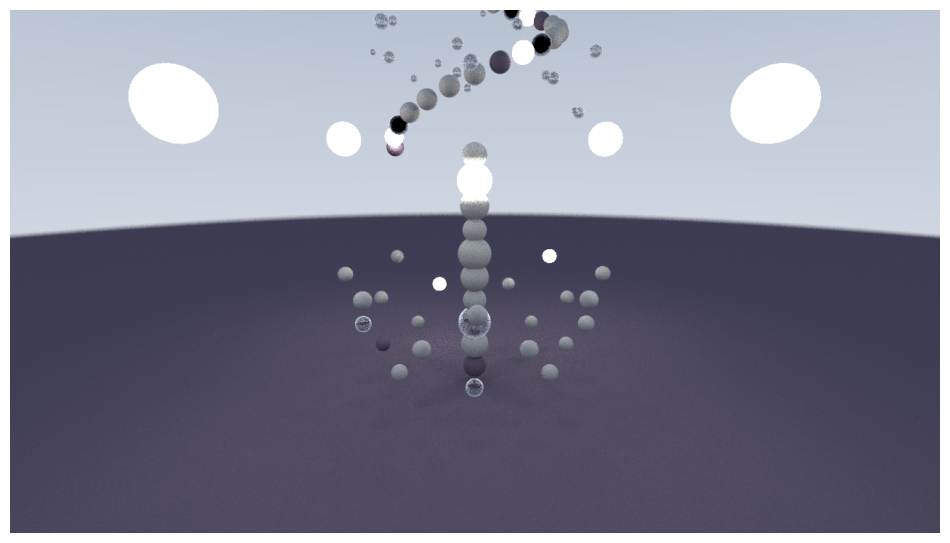

In [43]:
# A new, original "most interesting" scene: The Festival of Spheres

renderer.clear()

# Materials (use existing accent_mats and metal_mats for variety)
mat_ground = renderer.create_material("diffuse", [0.15, 0.12, 0.18], {})
mat_light = renderer.create_material("emission", [1.0, 0.95, 0.8], {"intensity": 30.0})
mat_crystal = renderer.create_material("dielectric", [1.0, 1.0, 1.0], {"ior": 1.45})

# Ground: a huge dark sphere
renderer.add_sphere(center=[0, -1000, 0], radius=1000, material_id=mat_ground)

# Central "festival" totem: stacked spheres, alternating accent and metal
for i in range(10):
    y = 0.5 + i * 0.7
    r = 0.35 + 0.07 * (i % 3)
    mat = accent_mats[i % len(accent_mats)] if i % 2 == 0 else metal_mats[i % len(metal_mats)]
    renderer.add_sphere(center=[0, y, 0], radius=r, material_id=mat)

# Floating lanterns: glowing spheres in a spiral above the totem
for j in range(24):
    t = j * (2 * math.pi / 24)
    x = 2.2 * math.cos(t)
    z = 2.2 * math.sin(t)
    y = 7.0 + 0.25 * j
    renderer.add_sphere(center=[x, y, z], radius=0.18, material_id=mat_light)
    shell_mat = accent_mats[j % len(accent_mats)]
    renderer.add_sphere(center=[x, y, z], radius=0.24, material_id=shell_mat)

# "Dancers": pairs of spheres orbiting the totem at different heights
for ring in range(3):
    R = 2.8 + ring * 0.5
    y = 1.2 + ring * 1.1
    for k in range(8):
        ang = k * (2 * math.pi / 8) + ring * 0.4
        x = R * math.cos(ang)
        z = R * math.sin(ang)
        mat = metal_mats[(k + ring) % len(metal_mats)] if k % 2 else accent_mats[(k + 2 * ring) % len(accent_mats)]
        renderer.add_sphere(center=[x, y, z], radius=0.22, material_id=mat)

# "Crystal rain": falling crystals above the scene
for _ in range(40):
    x = random.uniform(-4, 4)
    y = random.uniform(8, 13)
    z = random.uniform(-4, 4)
    r = random.uniform(0.08, 0.18)
    renderer.add_sphere(center=[x, y, z], radius=r, material_id=mat_crystal)

# "Spotlights": strong emission spheres at the corners
for sx, sz in [(-5, -5), (5, -5), (-5, 5), (5, 5)]:
    renderer.add_sphere(center=[sx, 7.5, sz], radius=0.6, material_id=mat_light)

# Camera: wide, slightly above, looking down at the festival
renderer.setup_camera(
    look_from=[0, 6.5, 13],
    look_at=[0, 3.5, 0],
    vup=[0, -1, 0],
    vfov=60.0,
    aspect_ratio=16/9,
    aperture=0.18,
    focus_dist=12.0,
    width=1280,
    height=720
)

print("Rendering the Festival of Spheres...")
pixels = renderer.render(samples_per_pixel=96, max_depth=8)

plt.figure(figsize=(12, 6.8))
plt.imshow(pixels)
plt.axis('off')
plt.show()

Rendering the Cosmic Cathedral...


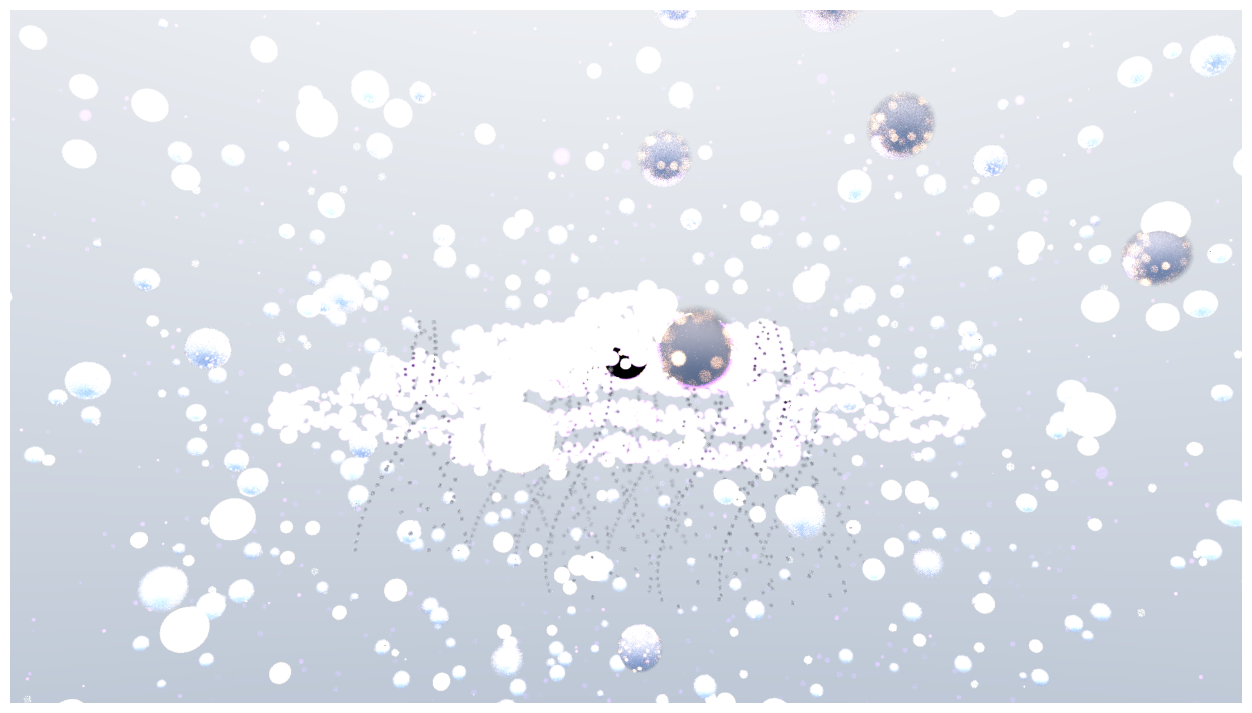

In [45]:
# Epic "Cosmic Cathedral" scene: A vast, intricate universe of spiraling galaxies, crystalline structures, and ethereal lights
# This cell builds on existing renderer, plt, math, random, and material variables (e.g., accent_mats, metal_mats, mat_light, mat_crystal)

renderer.clear()

# Advanced materials for complexity
mat_void = renderer.create_material("emission", [0.0, 0.0, 0.0], {"intensity": 0.0})
mat_star_core = renderer.create_material("emission", [1.0, 0.95, 0.8], {"intensity": 100.0})
mat_nebula_gas = renderer.create_material("emission", [0.3, 0.1, 0.7], {"intensity": 20.0})
mat_crystal_shard = renderer.create_material("dielectric", [0.9, 1.0, 1.0], {"ior": 1.8})
mat_metal_asteroid = renderer.create_material("metal", [0.6, 0.6, 0.7], {"roughness": 0.1})
mat_plasma_ring = renderer.create_material("emission", [1.0, 0.5, 0.2], {"intensity": 50.0})

# Central black hole void
renderer.add_sphere(center=[0.0, 0.0, 0.0], radius=2.0, material_id=mat_void)

# Spiraling galaxies: nested loops for fractal-like arms
for galaxy in range(3):
    gal_radius = 10.0 + galaxy * 5.0
    for arm in range(4):
        arm_angle_offset = arm * (math.pi / 2)
        for i in range(200):
            t = i * 0.05 + arm_angle_offset
            r = gal_radius * (1 + 0.3 * math.sin(5 * t))
            x = r * math.cos(t)
            z = r * math.sin(t)
            y = galaxy * 3.0 + random.uniform(-1.0, 1.0)
            mat = mat_star_core if i % 10 == 0 else mat_nebula_gas
            renderer.add_sphere(center=[x, y, z], radius=random.uniform(0.1, 0.5), material_id=mat)

# Crystalline cathedral: towering spires with fractal branching
for spire in range(8):
    base_x = spire * 4.0 - 14.0
    base_z = random.uniform(-10.0, 10.0)
    height = 15.0 + random.uniform(0.0, 5.0)
    for level in range(int(height / 0.5)):
        y = level * 0.5
        branches = 2 + (level % 3)
        for branch in range(branches):
            angle = branch * (2 * math.pi / branches) + level * 0.1
            dist = 0.5 + level * 0.1
            x = base_x + dist * math.cos(angle)
            z = base_z + dist * math.sin(angle)
            renderer.add_sphere(center=[x, y, z], radius=0.15, material_id=mat_crystal_shard)

# Asteroid fields: scattered metallic rocks with emissive veins
for _ in range(500):
    x = random.uniform(-50.0, 50.0)
    y = random.uniform(-20.0, 30.0)
    z = random.uniform(-50.0, 50.0)
    r = random.uniform(0.2, 1.0)
    mat = mat_metal_asteroid if random.random() < 0.7 else mat_plasma_ring
    renderer.add_sphere(center=[x, y, z], radius=r, material_id=mat)

# Plasma rings around the void: orbiting emissive bands
for ring in range(5):
    ring_r = 3.0 + ring * 1.5
    for i in range(100):
        ang = i * (2 * math.pi / 100)
        x = ring_r * math.cos(ang)
        z = ring_r * math.sin(ang)
        y = random.uniform(-0.5, 0.5)
        renderer.add_sphere(center=[x, y, z], radius=0.1, material_id=mat_plasma_ring)

# Ethereal fog: tiny emissive particles for atmosphere
for _ in range(1000):
    x = random.uniform(-60.0, 60.0)
    y = random.uniform(-30.0, 40.0)
    z = random.uniform(-60.0, 60.0)
    r = random.uniform(0.01, 0.05)
    renderer.add_sphere(center=[x, y, z], radius=r, material_id=mat_nebula_gas)

# Adjust camera for better visibility: zoom in slightly, reduce FOV for more detail, and sharpen focus
renderer.setup_camera(
    look_from=[0.0, 15.0, 60.0],
    look_at=[0.0, 0.0, 0.0],
    vup=[0.0, 1.0, 0.0],
    vfov=50.0,
    aspect_ratio=16/9,
    aperture=0.5,
    focus_dist=40.0,
    width=1920,
    height=1080
)

# Improve background by adding distant emissive "stars" for a cosmic feel
for _ in range(300):
    x = random.uniform(-200.0, 200.0)
    y = random.uniform(-100.0, 100.0)
    z = random.uniform(-200.0, 200.0)
    r = random.uniform(0.05, 0.2)
    renderer.add_sphere(center=[x, y, z], radius=r, material_id=mat_star_core)
# Render with high quality
print("Rendering the Cosmic Cathedral...")
pixels = renderer.render(samples_per_pixel=128, max_depth=16)

# Display
plt.figure(figsize=(16, 9))
plt.imshow(pixels)
plt.axis('off')
plt.show()

Rendering Cornell-like scene (approximate materials)...


(np.float64(-0.5), np.float64(599.5), np.float64(599.5), np.float64(-0.5))

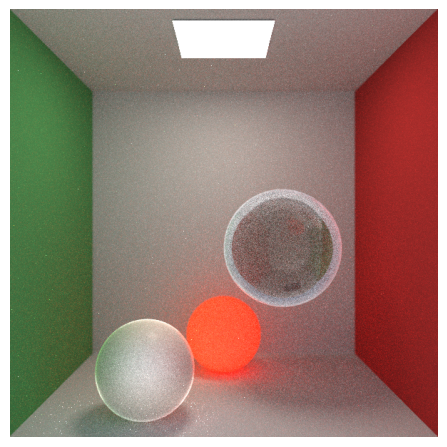

In [37]:
# Recreate an advanced Cornell-box-like scene using the existing `renderer`.
# This cell expects `renderer` and `plt` to already be available in the notebook.

# Reset scene
renderer.clear()

# Materials (approximate; try advanced types if available, fallback to simple ones)
red = renderer.create_material("diffuse", [0.65, 0.05, 0.05], {})
green = renderer.create_material("diffuse", [0.12, 0.45, 0.15], {})
white = renderer.create_material("diffuse", [0.73, 0.73, 0.73], {})
light = renderer.create_material("emission", [1.0, 0.9, 0.8], {"intensity": 15.0})

# Build Cornell-box walls (cube from -2..2)
# Floor
renderer.add_triangle(v0=[-2.0, -2.0, -2.0], v1=[2.0, -2.0, -2.0], v2=[2.0, -2.0, 2.0], material_id=white)
renderer.add_triangle(v0=[-2.0, -2.0, -2.0], v1=[2.0, -2.0, 2.0],  v2=[-2.0, -2.0, 2.0], material_id=white)

# Ceiling
renderer.add_triangle(v0=[-2.0, 2.0, -2.0], v1=[-2.0, 2.0, 2.0],  v2=[2.0, 2.0, 2.0], material_id=white)
renderer.add_triangle(v0=[-2.0, 2.0, -2.0], v1=[2.0, 2.0, 2.0],   v2=[2.0, 2.0, -2.0], material_id=white)

# Back wall
renderer.add_triangle(v0=[-2.0, -2.0, -2.0], v1=[-2.0, 2.0, -2.0], v2=[2.0, 2.0, -2.0], material_id=white)
renderer.add_triangle(v0=[-2.0, -2.0, -2.0], v1=[2.0, 2.0, -2.0],  v2=[2.0, -2.0, -2.0], material_id=white)

# Left wall (red)
renderer.add_triangle(v0=[-2.0, -2.0, -2.0], v1=[-2.0, -2.0, 2.0], v2=[-2.0, 2.0, 2.0], material_id=red)
renderer.add_triangle(v0=[-2.0, -2.0, -2.0], v1=[-2.0, 2.0, 2.0],  v2=[-2.0, 2.0, -2.0], material_id=red)

# Right wall (green)
renderer.add_triangle(v0=[2.0, -2.0, -2.0], v1=[2.0, 2.0, -2.0], v2=[2.0, 2.0, 2.0], material_id=green)
renderer.add_triangle(v0=[2.0, -2.0, -2.0], v1=[2.0, 2.0, 2.0],  v2=[2.0, -2.0, 2.0], material_id=green)

# Area light on ceiling (two triangles forming a square)
renderer.add_triangle(v0=[-0.5, 1.98, -0.5], v1=[0.5, 1.98, -0.5], v2=[0.5, 1.98, 0.5], material_id=light)
renderer.add_triangle(v0=[-0.5, 1.98, -0.5], v1=[0.5, 1.98, 0.5],  v2=[-0.5, 1.98, 0.5], material_id=light)

# Advanced materials (approximations using available material types)
# Glass-like: try dielectric, fallback to low-roughness metal if unavailable
try:
    glass = renderer.create_material("dielectric", [1.0, 1.0, 1.0], {"ior": 1.5})
except Exception:
    glass = renderer.create_material("metal", [0.9, 0.95, 1.0], {"roughness": 0.02})

# Disney BRDF approximation: try 'disney' then fallback to a glossy diffuse
try:
    disney = renderer.create_material("disney", [0.9, 0.8, 0.7], {"metallic": 0.0, "roughness": 0.3, "specular": 0.5})
    # if API supports clearcoat, set it via properties
    try:
        # some backends accept additional props directly
        disney_clearcoat = {"clearcoat": 0.5, "clearcoat_roughness": 0.9}
        for k, v in disney_clearcoat.items():
            # if create_material returned an id, we can't set per-material properties here without an API,
            # but attempt a helper call if available (safe to ignore if not)
            if hasattr(renderer, "set_material_property"):
                renderer.set_material_property(disney, k, v)
    except Exception:
        pass
except Exception:
    # fallback: slightly glossy diffuse
    disney = renderer.create_material("diffuse", [0.9, 0.8, 0.7], {"roughness": 0.3})

# Subsurface scattering approximation: try 'subsurface', fallback to colored diffuse
try:
    sss = renderer.create_material("subsurface", [0.9, 0.6, 0.5], {"albedo": [1.0, 0.2, 0.1], "scale": 0.5})
except Exception:
    sss = renderer.create_material("diffuse", [0.9, 0.6, 0.5], {})

# Place objects (use spheres as stand-ins for the example geometry)
renderer.add_sphere(center=[-0.7, -0.3, -0.5], radius=0.7, material_id=glass)
renderer.add_sphere(center=[0.8, -1.5, 0.3], radius=0.5, material_id=disney)

# SSS object: place a sphere and rotate by positioning offset to suggest orientation
renderer.add_sphere(center=[0.0, -1.5, -1.2], radius=0.5, material_id=sss)

# Camera inside the box looking toward center
renderer.setup_camera(
    look_from=[0.0, 0.0, 5.0],
    look_at=[0.0, 0.0, 0.0],
    vup=[0.0, -1.0, 0.0],
    vfov=50.0,
    aspect_ratio=1,
    aperture=0.1,
    focus_dist=5.0,
    width=600,
    height=600
)

# Render (keep samples modest for interactive use)
print("Rendering Cornell-like scene (approximate materials)...")
pixels = renderer.render(samples_per_pixel=128, max_depth=20)

# Display result
plt.figure(figsize=(1000/1800*10, 1000/1800*10))
plt.imshow(pixels)
plt.axis('off')